# Bibliotheken

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

# Daten

In [2]:
# Daten laden & Überblick gewinnen

df = pd.read_csv("../data/autoscout24.csv")
print("Datensatz geladen.")

Datensatz geladen.


In [3]:
df.head()

,mileage,make,model,fuel,gear,offerType,price,hp,year
0,235000,BMW,316,Diesel,Manual,Used,6800,116.0,2011
1,92800,Volkswagen,Golf,Gasoline,Manual,Used,6877,122.0,2011
2,149300,SEAT,Exeo,Gasoline,Manual,Used,6900,160.0,2011
3,96200,Renault,Megane,Gasoline,Manual,Used,6950,110.0,2011
4,156000,Peugeot,308,Gasoline,Manual,Used,6950,156.0,2011


### Spalten

- mileage = gefahrene Meilen
- make = Automarke
- model = Modell
- fuel = Brennstoffart
- gear (manual or automatic) = Getriebe (Schaltgetriebe oder Automatik) 
- offerType = Zustand (neu, gebraucht, ...)
- price = Verkaufspreis
- hp (horse power) = PS
- year = Zulassungsdatum | Jahr

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46405 entries, 0 to 46404
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mileage    46405 non-null  int64  
 1   make       46405 non-null  object 
 2   model      46262 non-null  object 
 3   fuel       46405 non-null  object 
 4   gear       46223 non-null  object 
 5   offerType  46405 non-null  object 
 6   price      46405 non-null  int64  
 7   hp         46376 non-null  float64
 8   year       46405 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 3.2+ MB


### Übersicht
- **Anzahl der Zeilen:** 46.405
- **Anzahl der Spalten:** 9
- **Nullwerte bei:** 
  - model = 143 
  - gear = 182 
  - hp = 29
  - &rarr; sehr wenig Missing Data

### Datentypen
- Datentypen sind in Ordnung
- ggf. ist hp als int ausreichend

In [5]:
# Datenqualität prüfen

# Fehlende Daten bearbeiten
# hp entfernen (29 -> sehr wenig) -> relevantes Feature für ML später (sollte sauber sein)
df = df.dropna(subset=['hp'])

# Kategorische Features mit 'Unknown' füllen
df['model'] = df['model'].fillna('Unknown')
df['gear'] = df['gear'].fillna('Unknown')

print("Fehlende Daten bereinigt.")

Fehlende Daten bereinigt.


In [6]:
# Duplikate finden
df[df.duplicated()]

,mileage,make,model,fuel,gear,offerType,price,hp,year
198,15,Fiat,Panda,Electric/Gasoline,Manual,Pre-registered,10980,69.0,2021
201,9,Toyota,Aygo,Gasoline,Manual,Pre-registered,11490,72.0,2021
202,9,Toyota,Aygo,Gasoline,Manual,Pre-registered,11490,72.0,2021
207,10,Toyota,Aygo,Gasoline,Manual,Pre-registered,11990,72.0,2021
208,10,Toyota,Aygo,Gasoline,Manual,Pre-registered,11990,72.0,2021
...,...,...,...,...,...,...,...,...,...
46400,99,Fiat,500,Electric/Gasoline,Manual,Pre-registered,12990,71.0,2021
46401,99,Fiat,500,Electric/Gasoline,Manual,Pre-registered,12990,71.0,2021
46402,99,Fiat,500,Electric/Gasoline,Manual,Pre-registered,12990,71.0,2021
46403,99,Fiat,500,Electric/Gasoline,Manual,Pre-registered,12990,71.0,2021


### Duplikate 
Es wurden 2135 Zeilen als Duplikate erkannt und vorerst behalten. Da Autos standardisierte Produkte sind, können identische Werte zufällig auftreten. 

&rarr; Um Verzerrungen zu vermeiden, werden für das ML-Modell die Duplikate mit 'drop_duplicates()' später entfernt.


### Inkonsistente Werte anschauen

In [7]:
# Inkonsistente Werte in den kategorischen Spalten finden
df['make'].value_counts()[df['make'].value_counts() < 10]

make
Lamborghini         9
Cadillac            7
Chrysler            5
Ligier              5
Piaggio             5
Alpine              5
Iveco               4
Trailer-Anhänger    4
Polestar            4
Baic                3
Rolls-Royce         3
Maybach             3
Corvette            3
Estrima             2
Morgan              2
Caravans-Wohnm      2
DFSK                2
Aixam               2
RAM                 2
Zhidou              1
9ff                 1
Tazzari             1
Trucks-Lkw          1
DAF                 1
FISKER              1
Brilliance          1
Isuzu               1
Name: count, dtype: int64

In [8]:
df['model'].value_counts()[df['model'].value_counts() < 5]

model
X2 M       4
Model X    4
V 200      4
Q30        4
XT4        4
          ..
S 260      1
e-Niro     1
A110       1
iX3        1
NV250      1
Name: count, Length: 285, dtype: int64

In [9]:
display(df['fuel'].value_counts())
display(df['gear'].value_counts())
display(df['offerType'].value_counts())

fuel
Gasoline             28850
Diesel               15244
Electric/Gasoline     1158
Electric               748
LPG                    125
CNG                    117
Others                  56
Electric/Diesel         53
-/- (Fuel)              22
Ethanol                  2
Hydrogen                 1
Name: count, dtype: int64

gear
Manual            30364
Automatic         15777
Unknown             179
Semi-automatic       56
Name: count, dtype: int64

offerType
Used              40103
Pre-registered     2779
Demonstration      2361
Employee's car     1120
New                  13
Name: count, dtype: int64

### Ausreißer erkennen

In [10]:
df.describe()

,mileage,price,hp,year
count,4.637600e+04,4.637600e+04,46376.000000,46376.000000
mean,7.116710e+04,1.657363e+04,132.990987,2016.012636
std,6.245573e+04,1.930839e+04,75.449284,3.154907
min,0.000000e+00,1.100000e+03,1.000000,2011.000000
25%,1.981750e+04,7.490000e+03,86.000000,2013.000000
50%,6.000000e+04,1.099900e+04,116.000000,2016.000000
75%,1.050000e+05,1.949000e+04,150.000000,2019.000000
max,1.111111e+06,1.199900e+06,850.000000,2021.000000


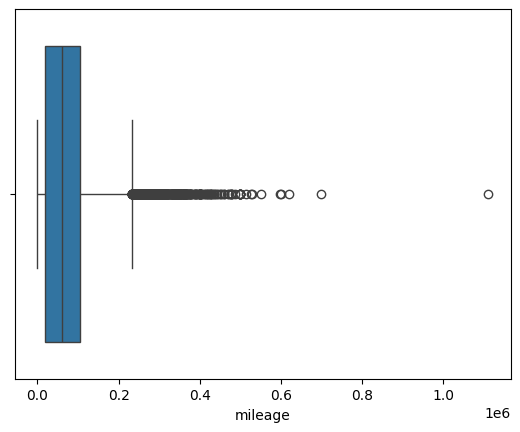

In [11]:
sns.boxplot(x=df['mileage'])
plt.show()

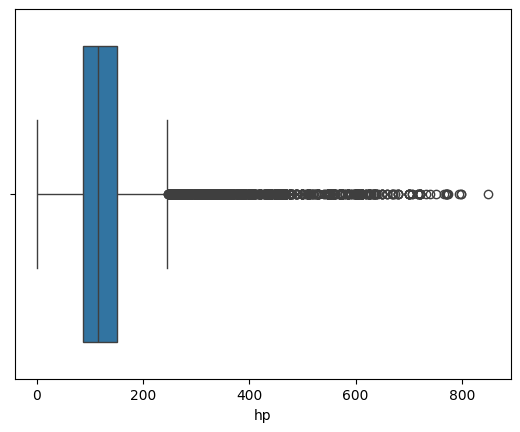

In [12]:
sns.boxplot(x=df['hp'])
plt.show()

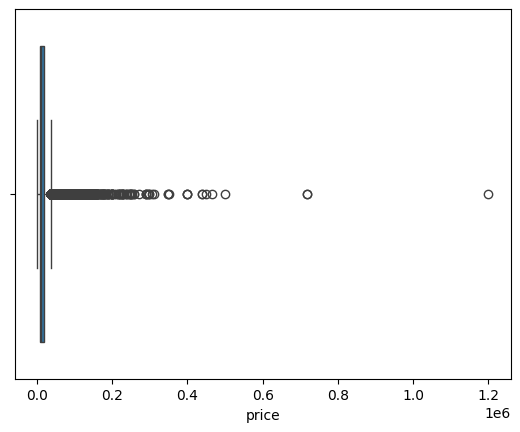

In [13]:
sns.boxplot(x=df['price'])
plt.show()

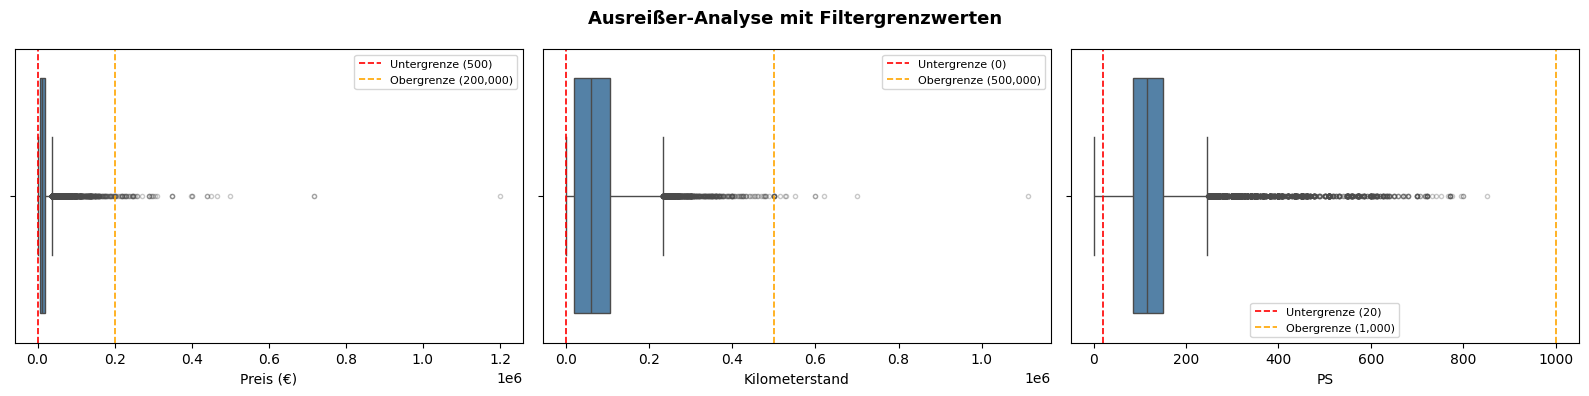

In [ ]:
# Boxplots zeigen Ausreißer, mit Annotationen der Filtergrenzen 

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, low, high, label in [
    (axes[0], 'price',   500,    200_000, 'Preis (€)'),
    (axes[1], 'mileage', 0,      500_000, 'Kilometerstand'),
    (axes[2], 'hp',      20,     1_000,   'PS'),
]:
    sns.boxplot(x=df[col], ax=ax, color='steelblue', flierprops=dict(marker='.', alpha=0.3))
    ax.axvline(low,  color='red',   linestyle='--', linewidth=1.2, label=f'Untergrenze ({low:,})')
    ax.axvline(high, color='orange',linestyle='--', linewidth=1.2, label=f'Obergrenze ({high:,})')
    ax.set_xlabel(label)
    ax.legend(fontsize=8)

fig.suptitle('Ausreißer-Analyse mit Filtergrenzwerten', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

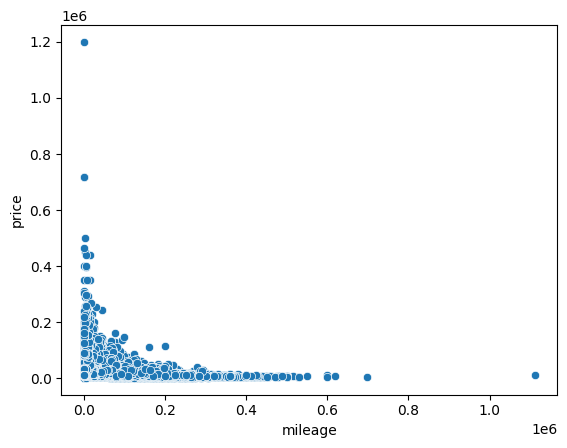

In [16]:
sns.scatterplot(data=df, x='mileage', y='price')
plt.show()

<Axes: xlabel='price', ylabel='Count'>

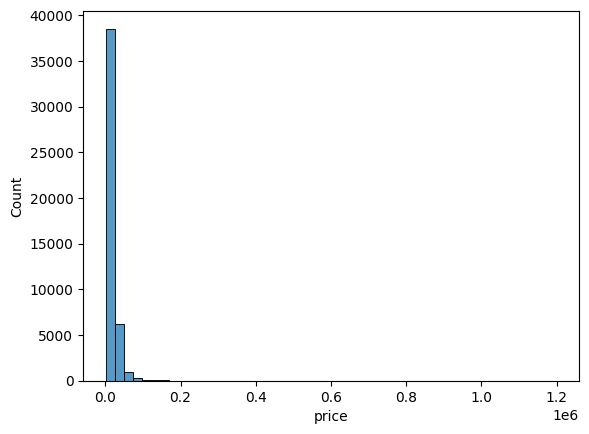

In [17]:
sns.histplot(df['price'], bins=50)


### Was ist realistisch bei Autos?

**Preis**:
- < 500 €: Schrottautos
- 200.000 €: Luxusautos (seltener, aber real)
- 500.000 €: fast immer Ausreißer
  
**Kilometerstand**:
- < 1.000 km &rarr; Neuwagen
- 500.000 km &rarr; ungewöhnlich
- 1.000.000 km &rarr; fast sicher falsch

**PS**:
- <40 PS &rarr; Leichtfahrzeuge
- 600 PS &rarr; Supersportwagen

# Analyse

In [18]:
# Wie viele Autos wurden verkauft?
print("Anzahl der verkauften Autos: ", df.shape[0]) # 46376

# Über welchen Zeitraum?
print("Erstzulassungen: ", df['year'].min(), "-", df['year'].max())

Anzahl der verkauften Autos:  46376
Erstzulassungen:  2011 - 2021


In [19]:
# Herstellerliste
print("Es sind", df['make'].nunique(), "Hersteller im Datensatz enthalten.\n")
list_of_makes = list(df['make'].unique())
list_of_makes_ordered = sorted(list_of_makes)

for entry in list_of_makes_ordered:
    print(entry)

Es sind 77 Hersteller im Datensatz enthalten.

9ff
Abarth
Aixam
Alfa
Alpina
Alpine
Aston
Audi
BMW
Baic
Bentley
Brilliance
Cadillac
Caravans-Wohnm
Chevrolet
Chrysler
Citroen
Corvette
Cupra
DAF
DFSK
DS
Dacia
Daihatsu
Dodge
Estrima
FISKER
Ferrari
Fiat
Ford
Honda
Hyundai
Infiniti
Isuzu
Iveco
Jaguar
Jeep
Kia
Lada
Lamborghini
Lancia
Land
Lexus
Ligier
MINI
Maserati
Maybach
Mazda
McLaren
Mercedes-Benz
Microcar
Mitsubishi
Morgan
Nissan
Opel
Others
Peugeot
Piaggio
Polestar
Porsche
RAM
Renault
Rolls-Royce
SEAT
Skoda
SsangYong
Subaru
Suzuki
Tazzari
Tesla
Toyota
Trailer-Anhänger
Trucks-Lkw
Volkswagen
Volvo
Zhidou
smart


In [20]:
# Häufigkeit pro Marke
df['make'].value_counts().head(20)

make
Volkswagen       6931
Opel             4809
Ford             4440
Skoda            2888
Renault          2829
Audi             2684
BMW              2404
Mercedes-Benz    2353
SEAT             1924
Hyundai          1887
Fiat             1696
Toyota           1275
Peugeot          1230
Kia              1055
smart             973
Citroen           956
Volvo             804
Nissan            753
Mazda             714
Dacia             713
Name: count, dtype: int64

In [21]:
# PS nach int casten
df['hp'] = df['hp'].astype('int64')

# Numerische Features identifizieren
df.info() # mileage, price, hp, year

<class 'pandas.core.frame.DataFrame'>
Index: 46376 entries, 0 to 46404
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   mileage    46376 non-null  int64 
 1   make       46376 non-null  object
 2   model      46376 non-null  object
 3   fuel       46376 non-null  object
 4   gear       46376 non-null  object
 5   offerType  46376 non-null  object
 6   price      46376 non-null  int64 
 7   hp         46376 non-null  int64 
 8   year       46376 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.5+ MB


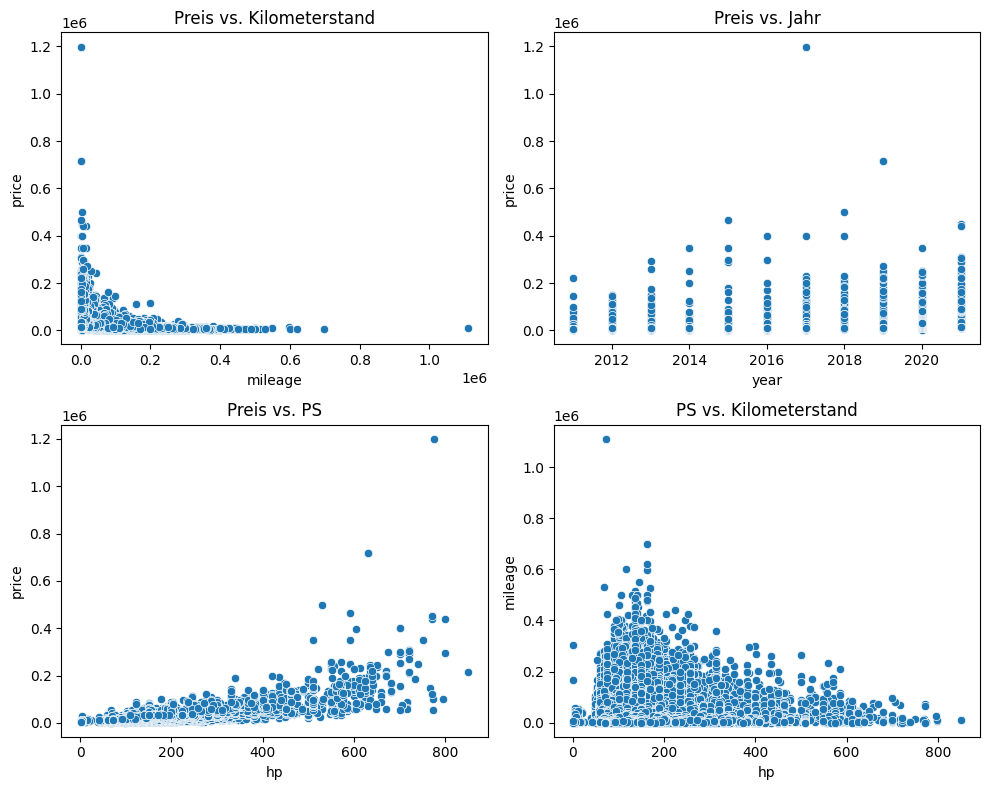

In [22]:
# Scatterplots, um Korrelationen zu untersuchen

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.scatterplot(ax=axes[0, 0], data=df, x='mileage', y='price')
axes[0, 0].set_title('Preis vs. Kilometerstand')

sns.scatterplot(ax=axes[0, 1], data=df, x='year', y='price')
axes[0, 1].set_title('Preis vs. Jahr')

sns.scatterplot(ax=axes[1, 0], data=df, x='hp', y='price')
axes[1, 0].set_title('Preis vs. PS')

sns.scatterplot(ax=axes[1, 1], data=df, x='hp', y='mileage')
axes[1, 1].set_title('PS vs. Kilometerstand')

plt.tight_layout()
plt.show()

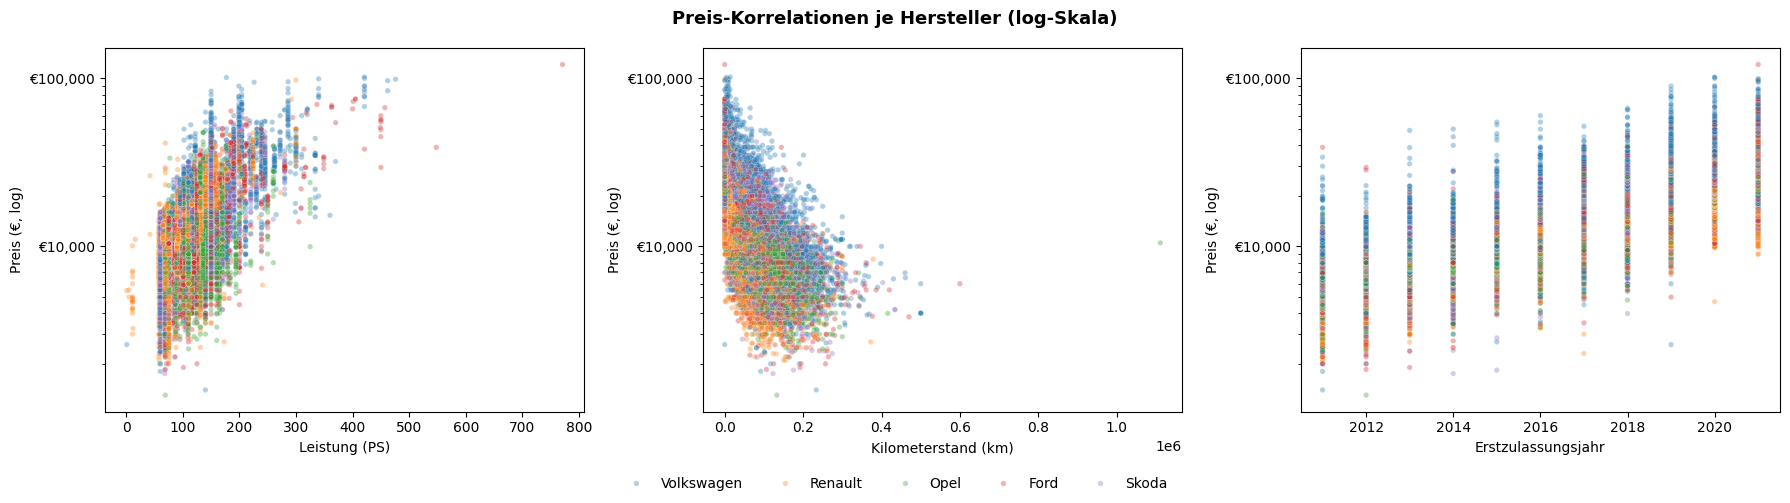

In [ ]:
# `hue='make'` und Log-Skala zeigen die Spreizung bei hohen Preisen und lassen die Marken-Cluster erkennbar werden
top_5 = df['make'].value_counts().head(5).index
df_plot = df[df['make'].isin(top_5)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, x_col, xlabel in [
    (axes[0], 'hp',      'Leistung (PS)'),
    (axes[1], 'mileage', 'Kilometerstand (km)'),
    (axes[2], 'year',    'Erstzulassungsjahr'),
]:
    sns.scatterplot(
        ax=ax, data=df_plot,
        x=x_col, y='price',
        hue='make', alpha=0.35, s=15,
        palette='tab10'
    )
    ax.set_yscale('log')                         # Log-Skala dämpft Extremwerte
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Preis (€, log)')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'€{int(v):,}')
    )
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, frameon=False)
fig.suptitle('Preis-Korrelationen je Hersteller (log-Skala)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


In [25]:
# Korrelationsmatrix

corr = df[['price', 'mileage', 'hp', 'year']].corr()
corr

,price,mileage,hp,year
price,1.000000,-0.303255,0.747617,0.405526
mileage,-0.303255,1.000000,-0.015086,-0.677564
hp,0.747617,-0.015086,1.000000,0.167232
year,0.405526,-0.677564,0.167232,1.000000


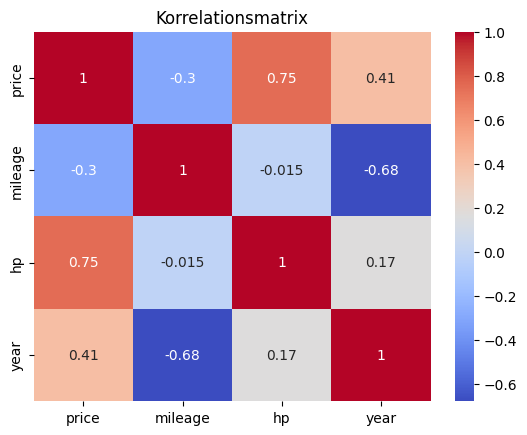

In [26]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korrelationsmatrix')
plt.show()


### Interpretation

1. Je mehr km, desto geringer der Preis. &rarr; Schwacher bis mittlerer negativer Zusammenhang: -0.30
2. Die Preise steigen tendenziell mit dem Jahr der Zulassung. &rarr; Mittlerer positiver Zusammenhang: +0.41
3. Je mehr Leistung (PS), desto teurer das Auto. &rarr; positiver Zusammenhang: +0.75
4. Je mehr Leistung (PS), desto weniger gefahrene Strecke (km). &rarr; Praktisch kein Zusammenhang: -0.015
5. Neuere Autos, weniger gefahrene Strecke. &rarr; Starker negativer Zusammenhang: -0.68
6. Neuere Autos, etwas mehr Leistung (PS). &rarr; Schwacher positiver Zusammenhang: +0.17

**Zusammenfassung:**
Es gibt klare Zusammenhänge zwischen den numerischen Werten: 

Leistungsstarke und neuere Fahrzeuge sind teurer, während hohe Laufleistungen den Preis reduzieren.
Der Preis korreliert stark positiv mit der Leistung und moderat positive mit dem Zulassungsjahr.

**Welche KPIs beeinflussen somit den Preis am stärksten?**

| KPI | Einflussstärke | Richtung|
|:----|:----:|----:|
| Leistung (PS) | sehr stark | Preis steigt |
| Zulassungsjahr (Alter) | mittel | Preis steigt |
| Laufleistung (km) | moderat | Preis fällt |

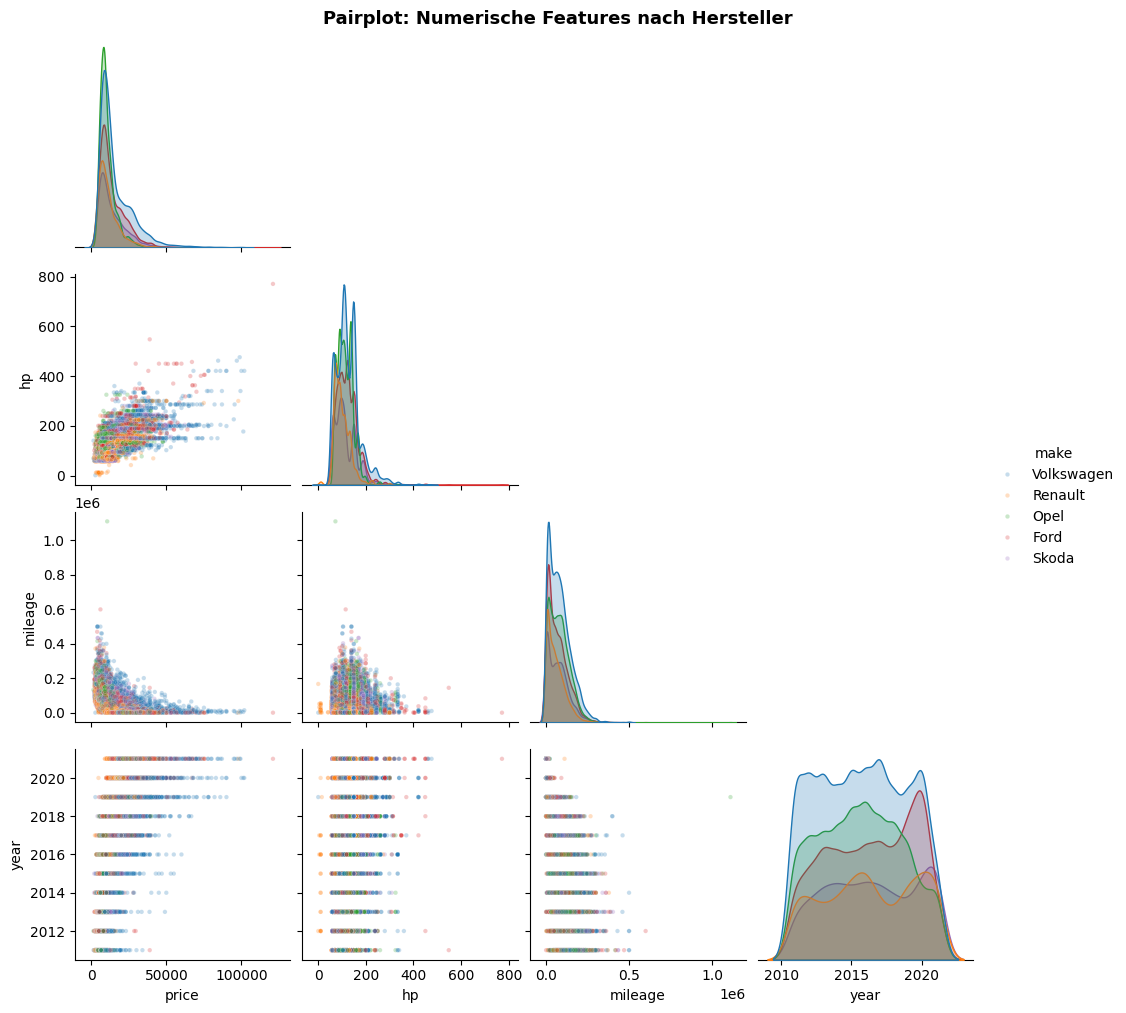

In [27]:
# Pairplot zeigt die tatsächliche Form der Beziehungen (linear? kurvenförmig? bimodal?) — und auf der Diagonale die Verteilung je Feature.

top_5 = df['make'].value_counts().head(5).index

g = sns.pairplot(
    df[df['make'].isin(top_5)][['price', 'hp', 'mileage', 'year', 'make']],
    hue='make',
    plot_kws=dict(alpha=0.25, s=10),
    diag_kind='kde',
    corner=True,          # nur untere Hälfte – spart Platz
    palette='tab10'
)
g.figure.suptitle('Pairplot: Numerische Features nach Hersteller', y=1.01, fontsize=13, fontweight='bold')
plt.show()


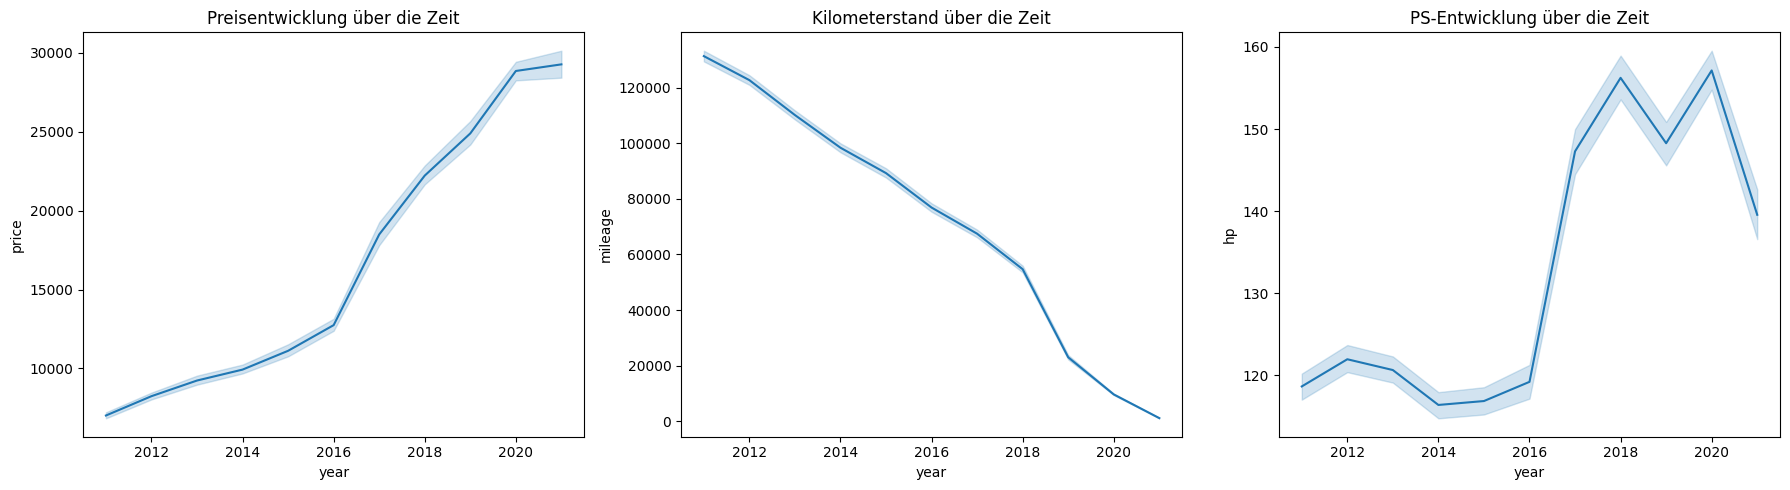

In [28]:
# Veränderungen über die Zeit

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(ax=axes[0], data=df, x='year', y='price')
axes[0].set_title('Preisentwicklung über die Zeit')

sns.lineplot(ax=axes[1], data=df, x='year', y='mileage')
axes[1].set_title('Kilometerstand über die Zeit')

sns.lineplot(ax=axes[2], data=df, x='year', y='hp')
axes[2].set_title('PS-Entwicklung über die Zeit')

plt.tight_layout()
plt.show()


### Interpretation:
1. Autos werden über die Jahre deutlich teurer.
2. Je neuer das Zulassungsjahr, desto geringer der Kilometerstand (logisch!).
3. Die durchschnittliche Motorenleistung steigt über die Jahre an, besonders ab 2017. 

In [29]:
# Herstellertrends der TOP 5 Hersteller

# Anzahl der Inserate pro Hersteller
trend = df.groupby(['year', 'make']).size().reset_index(name='count')

# Durchschnittspreis pro Hersteller
price_avg = df.groupby(['year', 'make'])['price'].mean().reset_index()

# TOP 5 Hersteller bestimmen
top_5 = df['make'].value_counts().head(5).index

# Auf TOP 5 filtern
trend_top_5 = trend[trend['make'].isin(top_5)]
price_avg_top_5 = price_avg[price_avg['make'].isin(top_5)]

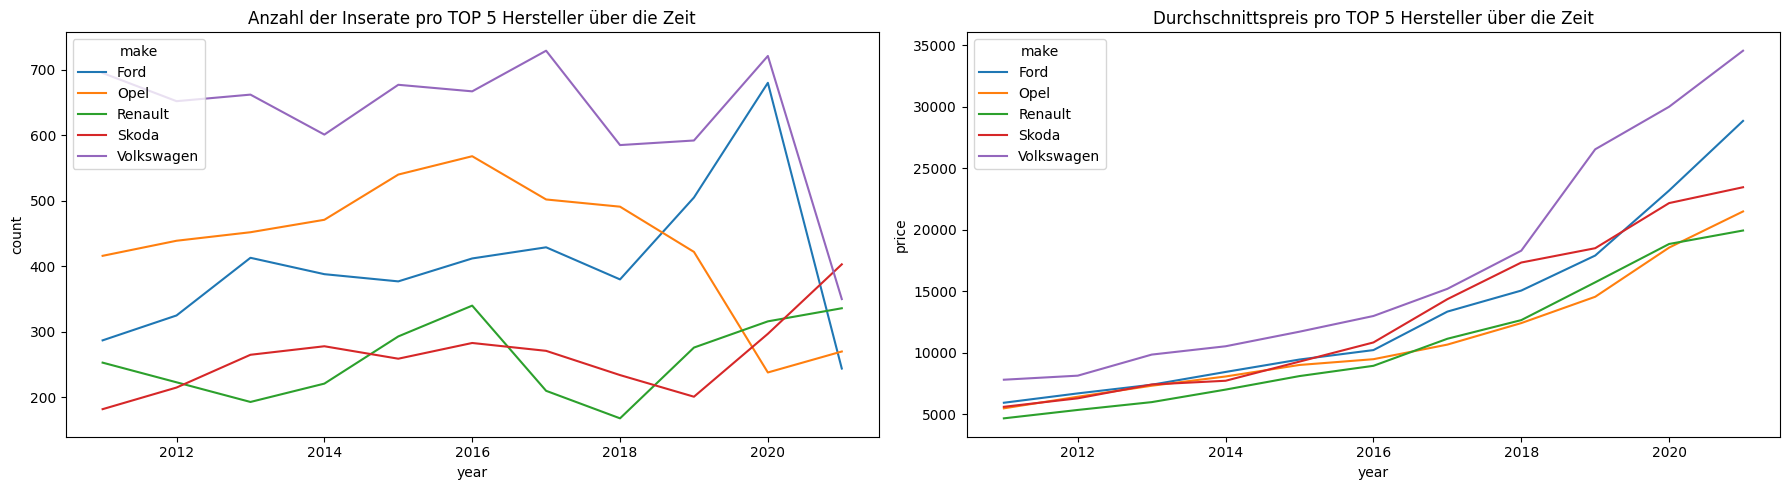

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.lineplot(ax=axes[0], data=trend_top_5, x='year', y='count', hue='make')
axes[0].set_title('Anzahl der Inserate pro TOP 5 Hersteller über die Zeit')

sns.lineplot(ax=axes[1], data=price_avg_top_5, x='year', y='price', hue='make')
axes[1].set_title('Durchschnittspreis pro TOP 5 Hersteller über die Zeit')

plt.tight_layout()
plt.show()

### Interpretation

**Anzahl der Inserate:**
- Volkswagen dominiert den Markt.
- Opel, Ford, Skoda und Renault folgen einem ähnlichen Muster. 
- Die Anzahl der Inserate steigt bei allen Herstellern bis ca. 2017-2018 an und fällt danach leicht ab.
  
&rarr; VW dominiert den Markt, während die anderen Hersteller stabile, aber deutlich kleinere Marktanteile haben. 

**Durchschnittspreis pro Hersteller:**
- Volkswagen hat durchgehend den höchsten Durchschnittspreis. 
- Skoda und Ford liegen im Mittelfeld.
- Opel und Renault haben den niedrigsten Durchschnittspreis. 

&rarr; VW ist preislich klar führend, während Opel und Renault die günstigsten Marken im TOP-5-Vergleich sind. Alle Hersteller zeigen einen deutlichen Preisanstieg über die Jahre.

C:\Users\eiend\AppData\Local\Temp\ipykernel_13992\1668315682.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


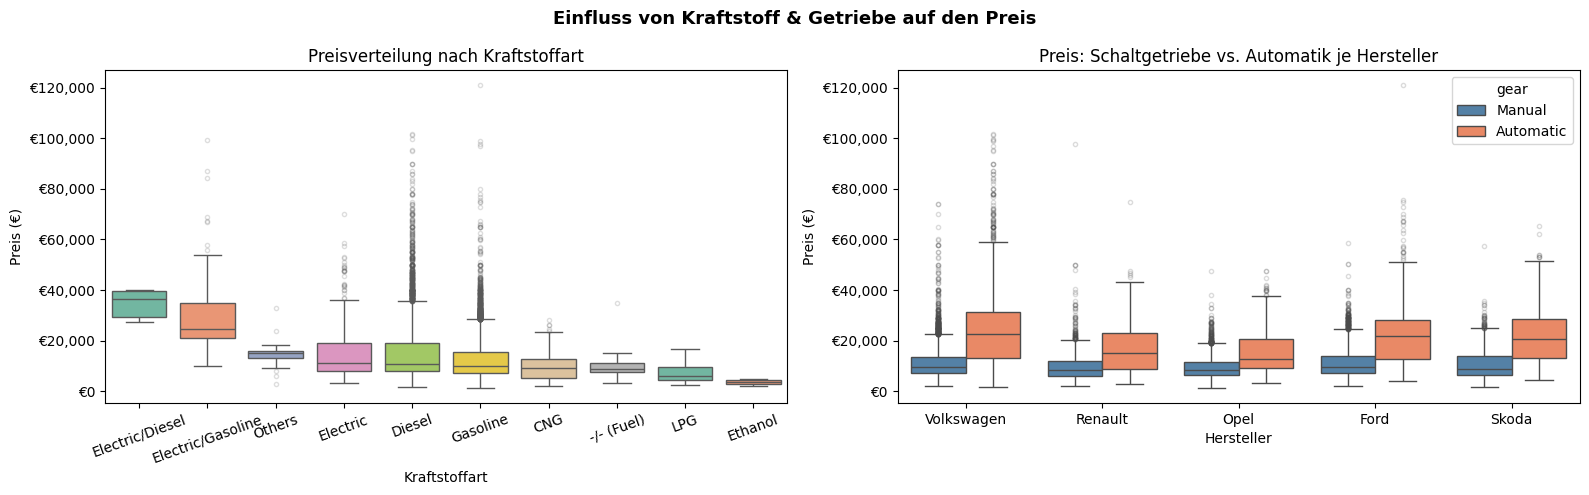

In [31]:
# Boxplots zeigen den Preiseinfluss
top_5 = df['make'].value_counts().head(5).index
df5 = df[df['make'].isin(top_5) & df['price'].between(500, 200_000)]

# Nur die relevanten Kraftstoffarten
fuel_order = df5.groupby('fuel')['price'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    ax=axes[0], data=df5,
    x='fuel', y='price',
    order=fuel_order,
    palette='Set2', flierprops=dict(marker='.', alpha=0.2)
)
axes[0].set_title('Preisverteilung nach Kraftstoffart')
axes[0].set_xlabel('Kraftstoffart')
axes[0].set_ylabel('Preis (€)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{int(v):,}'))

sns.boxplot(
    ax=axes[1], data=df5[df5['gear'].isin(['Manual', 'Automatic'])],
    x='make', y='price', hue='gear',
    palette={'Manual': 'steelblue', 'Automatic': 'coral'},
    flierprops=dict(marker='.', alpha=0.2)
)
axes[1].set_title('Preis: Schaltgetriebe vs. Automatik je Hersteller')
axes[1].set_xlabel('Hersteller')
axes[1].set_ylabel('Preis (€)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{int(v):,}'))

plt.suptitle('Einfluss von Kraftstoff & Getriebe auf den Preis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


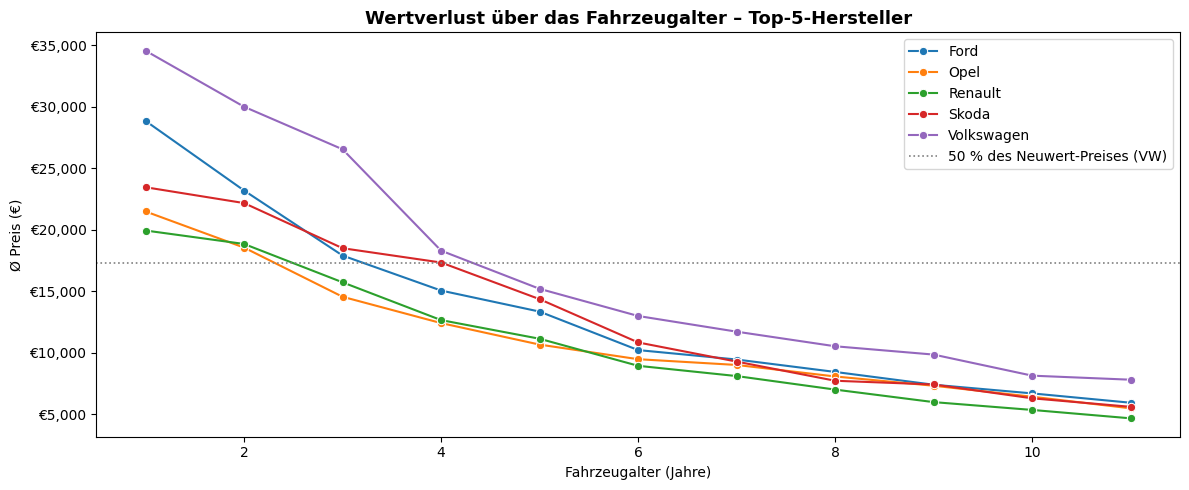

In [33]:
# Wertverlust über das Fahrzeugalter der TOP-5-Hersteller

top_5 = df['make'].value_counts().head(5).index
df5 = df[df['make'].isin(top_5) & df['price'].between(500, 200_000)].copy()

# Fahrzeugalter berechnen (analog zu machine_learning.ipynb)
df5['car_age'] = df5['year'].max() + 1 - df5['year']

wertverlust = (
    df5.groupby(['car_age', 'make'])['price']
    .agg(['mean', 'count'])
    .reset_index()
    .query('count >= 5')           # Altersklassen mit wenig Daten ausblenden
    .rename(columns={'mean': 'avg_price', 'make': 'Hersteller'})
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    data=wertverlust, x='car_age', y='avg_price',
    hue='Hersteller', marker='o', palette='tab10', ax=ax
)

# 50%-Referenzlinie (halber Startpreis VW als Beispiel)
ax.axhline(
    wertverlust.query("Hersteller == 'Volkswagen' and car_age == 1")['avg_price'].values[0] / 2,
    color='grey', linestyle=':', linewidth=1.2, label='50 % des Neuwert-Preises (VW)'
)

ax.set_xlabel('Fahrzeugalter (Jahre)')
ax.set_ylabel('Ø Preis (€)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'€{int(v):,}'))
ax.set_title('Wertverlust über das Fahrzeugalter – Top-5-Hersteller', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()